In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

Langgraph에서 말하는 그래프느는 업무의 흐름도!

- **유연성**: 상황에 따라 다른 경로로 처리  
- **확장성**: 새로운 작업자(노드) 추가 용이  
- **디버깅**: 각 단계별 상태 추적 가능  
- **재사용**: 만들어진 그래프를 다른 곳에서도 활용


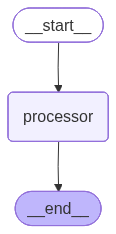

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class SimpleState(TypedDict):
    """Simple state with a single field"""
    message: str

graph_builder = StateGraph(SimpleState)

# 노드 함수 정의의
def processor(state:SimpleState):
    """Procss the message in the state"""
    return {"message": state["message"]+" - processed"}

graph_builder.add_node("processor", processor)

graph_builder.add_edge(START, "processor")
graph_builder.add_edge("processor", END)


graph = graph_builder.compile()
graph

In [3]:
result = graph.invoke({"message": "Hello LangGraph"})
print(f"{result}")

{'message': 'Hello LangGraph - processed'}


그래프를 만든 후에는 반드시 컴파일 해야한다. 이는  최종 점검과 같다.

1. 구조 검증: "모든 작업자가 제자리에 있나?"
   - 연결되지 않은 노드(고아 노드) 확인
   - 실행 경로가 제대로 이어져 있는지 검증

2. 설정 적용: "특별한 옵션이 필요한가?"
   - 체크포인터: 중간 결과 저장소 설정
   - 브레이크포인트: 디버깅을 위한 중단점

3. 실행 준비: "이제 언제든 가동할 수 있어!"
   - 최적화된 실행 가능한 객체 생성

컴파일 옵션들

- **checkpointer**: 그래프 실행 중간에 상태를 저장 (메모리 기능!)
- **interrupt_before**: 특정 노드 실행 **전**에 일시정지
- **interrupt_after**: 특정 노드 실행 **후**에 일시정지


In [4]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

graph_with_memory = graph_builder.compile(
    checkpointer=memory,  # 상태 저장을 위한 체크포인터
)

In [5]:
from langchain_core.runnables import RunnableConfig

# 체크포인터를 사용할 때는 thread_id 등 런어블 설정이 필요합니다.
config = RunnableConfig(thread_id="test-thread-1")
graph_with_memory.invoke({"message": "Hello~ My name is Jaeho"}, config=config)

{'message': 'Hello~ My name is Jaeho - processed'}

# State 스키마 정의 방법 3가지

#### 1. **TypedDict 방식** 
```python
class MyState(TypedDict):
    name: str
    count: int
```
- **장점**: 가벼움, 빠름, 간단함
- **단점**: 기본값 설정이 번거로움
- **언제 사용**: 대부분의 경우

#### 2. **Dataclass 방식**
```python
@dataclass
class MyState:
    name: str = "기본값"
    count: int = 0
```
- **장점**: 기본값 설정 쉬움
- **단점**: TypedDict보다 약간 무거움
- **언제 사용**: 기본값이 많이 필요할 때

#### 3. **Pydantic 방식**
```python
class MyState(BaseModel):
    name: str = "기본값"
    count: int = 0
```
- **장점**: 강력한 유효성 검증
- **단점**: 가장 무거움, 복잡함
- **언제 사용**: 엄격한 데이터 검증이 필요할 때, Description이 필요할 때(LLM이 참고함)

In [6]:
from typing import Annotated, List
from dataclasses import dataclass, field
from pydantic import BaseModel, Field

class TypedDictState(TypedDict):
    """State using TypedDict"""
    count: int
    items: List[str]

# 기본값 지원
@dataclass
class DataclassState:
    """State using dataclass with default values"""

    count: int = 0
    items: List[str] = field(default_factory=list)

class PydanticState(BaseModel):
    """State using Pydantic for validation"""

    count: int = Field(0, description="상태의 카운트 수. 기본값은 0입니다.")
    items: List[str] = Field(default_factory=list, description="상태에 저장되는 문자열 목록. 기본값은 빈 리스트입니다.")

# 리듀서(Reducers): 업데이트 규칙 관리자
새로운 정보가 들어왔을 때, 기존 정보와 어떻게 합칠까?

- 기본 리듀서: 설정값,현재 상태 등 (예: 현재_온도)
새 값으로 완전 교체
```python
재고_수량: int  # 새 값으로 완전히 교체
```
예시: "사과 10개" → "사과 15개" (10개는 사라지고 15개가 됨)

- add 리듀서: 메시지, 로그, 히스토리 등 (예: 대화_내역)  
기전 목록에 추가
```python
주문_목록: Annotated[List[str], add]  # 기존 목록에 추가
```
예시: ["사과", "바나나"] + ["오렌지"] = ["사과", "바나나", "오렌지"]


- 커스텀 리듀서 (최대값 유지): 특별한 로직이 필요할 때 (예: 최고_점수)
```python
최고_판매량: Annotated[int, lambda old, new: max(old, new)]
```
예시: 기존 50개, 새로 30개 → 50개 유지 (더 큰 값 선택)

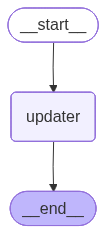

In [7]:
from operator import add

# 기본 리듀서 vs 커스텀 리듀서
class StateWithReducers(TypedDict):
    """State with custom reducers"""

    # 기본 리듀서: 값을 덮어씀
    current_value: int

    # add 리듀서: 리스트를 연결
    history: Annotated[List[str], add]

    # 커스텀 리듀서: 최대값 유지
    max_value: Annotated[int, lambda x, y: max(x, y)]

builder = StateGraph(StateWithReducers)

def update_values(state: StateWithReducers):
    """Update various state values"""
    return {
        "current_value": 10,  # 덮어쓰기
        "history": ["새 항목"],  # 추가
        "max_value": 15,  # 최대값과 비교
    }

builder.add_node("updater", update_values)
builder.add_edge(START, "updater")
builder.add_edge("updater", END)

graph = builder.compile()


graph

In [8]:
# 초기 상태로 실행
initial_state = {"current_value": 5, "history": ["초기 항목"], "max_value": 20}

result = graph.invoke(initial_state)
print("\n리듀서 적용 결과:")
print(f"  current_value: 5 → {result['current_value']} (덮어쓰기)")
print(f"  history: {result['history']} (추가)")
print(f"  max_value: {result['max_value']} (최대값 유지)")


리듀서 적용 결과:
  current_value: 5 → 10 (덮어쓰기)
  history: ['초기 항목', '새 항목'] (추가)
  max_value: 20 (최대값 유지)


### LangGraph의 메시지 시스템

1: `add_messages` 리듀서 사용 (직접 정의)
```python
class ChatState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]
    metadata: dict  # 부가 정보
```

2: `MessagesState` 상속 (⭐ 더 간단!)
```python
class ExtendedChatState(MessagesState):
    # messages는 이미 정의되어 있음!
    metadata: dict  # 필요한 것만 추가
```

### 메시지 타입들

- **HumanMessage**: 사용자가 보낸 메시지
- **AIMessage**: AI가 답변한 메시지  
- **SystemMessage**: 시스템 지시사항
- **ToolMessage**: 도구 실행 결과
- **AnyMessage**: 정의된 메시지 또는 메시지 청크

In [9]:
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langgraph.graph.message import add_messages
from langgraph.graph import MessagesState

# 1. add_messages 리듀서 사용
class ChatState(TypedDict):
    """State with add_messages reducer"""

    messages: Annotated[List[AnyMessage], add_messages]
    metadat: dict

# 2.MessageState 상속 
class ExtendedChatState(MessagesState):
    """Extended state ingeriting from MessagesState"""
    # messages키는 이미 정의 되어 있음.
    metadata: dict

In [10]:
from langchain_core.runnables import RunnableConfig

builder = StateGraph(ChatState)

def process_chat(state: ChatState):
    """Process chat messages"""
    last_message = state["messages"][-1]

    # 응답 생성
    response = AIMessage(content=f"{last_message.content}")

    return {
        "messages": [response], # add_messages가 자동으로 추가
        "metadata": {"processed": True},
    }

builder.add_node("chat", process_chat)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

memory = InMemorySaver()
chat_graph = builder.compile(checkpointer=memory)

In [11]:
config = RunnableConfig(configurable={"thread_id": "1"})

# 실행
result = chat_graph.invoke(
    {
        "messages": [HumanMessage(content="안녕하세요")],
        "metadata": {},
        "user_info": {"name": "사용자"},
    },
    config=config,
)

print("\n메시지 처리 결과:")
for msg in result["messages"]:
    # msg.__class__는 해당 객체의 클래스(타입)를 반환하고,
    # .__name__은 클래스의 이름(str)을 반환함.
    # 즉, 이 코드는 메시지 객체가 어떤 타입인지 (예: HumanMessage, AIMessage 등) 이름을 나타내 줌.
    print(f"  [{msg.__class__.__name__}]: {msg.content}")


메시지 처리 결과:
  [HumanMessage]: 안녕하세요
  [AIMessage]: 안녕하세요


# 스키마

#### **InputState** - 입구에서 받는 정보
- 그래프가 시작할 때 **사용자가 제공하는 데이터**의 형태
- 예시: 사용자 질문, 업로드한 파일, 설정값 등

#### **InternalState** - 내부에서 사용하는 정보  
- 그래프 **내부 노드들이 실제로 사용하는** 데이터 구조
- 예시: 중간 처리 결과, 임시 데이터, 내부 상태값 등

#### **OutputState** - 최종 결과물
- 그래프가 **완료되었을 때 사용자에게 반환하는** 데이터 형태
- 예시: 최종 답변, 처리 결과, 요약 정보 등

In [12]:
# 그래프의 입력 스키마
class InputState(TypedDict):
    """Input schema - what users provide"""

    user_input: str


# 그래프의 출력 스키마
class OutputState(TypedDict):
    """Output schema - what users receive"""

    graph_output: str


# 내부에서 사용되는 State
class InternalState(TypedDict):
    """Internal schema - full state for processing"""

    user_input: str
    internal_state: str


# Private State
class PrivateState(TypedDict):
    """Private schema - for internal node communication"""

    private_state: str

In [13]:
builder = StateGraph(
    InternalState,
    input_schema=InputState,
    output_schema=OutputState,
)

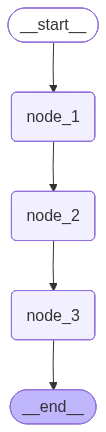

In [14]:
def node_1(state: InputState) -> InternalState:
    """First node - reads from InputState, writes to InternalState"""
    # InputState를 받지만 InternalState의 키에 쓸 수 있음
    print(f"node_1: {state}")
    return {
        "user_input": state["user_input"],
        "internal_state": state["user_input"] + "(node_1 에서 처리됨)",
    }


def node_2(state: InternalState) -> PrivateState:
    """Second node - reads from InternalState, writes to PrivateState"""
    print(f"node_2: {state}")
    # 새로운 state 채널(temp_data) 추가 가능
    return {"private_state": f"PRIVATE: {state['internal_state']} (node_2 에서 처리됨)"}


def node_3(state: PrivateState) -> OutputState:
    """Final node - reads from PrivateState, writes to OutputState"""
    print(f"node_3: {state}")
    return {"graph_output": f"최종 결과: {state['private_state']} (node_3 에서 처리됨)"}


# 노드와 엣지 추가
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

multi_schema_graph = builder.compile()
multi_schema_graph


In [15]:

# 실행 - 입력은 InputState 형식
result = multi_schema_graph.invoke({"user_input": "사용자 입력"})

# 출력은 OutputState 형식
print(f"\n다중 스키마 결과: {result}")

node_1: {'user_input': '사용자 입력'}
node_2: {'user_input': '사용자 입력', 'internal_state': '사용자 입력(node_1 에서 처리됨)'}
node_3: {'private_state': 'PRIVATE: 사용자 입력(node_1 에서 처리됨) (node_2 에서 처리됨)'}

다중 스키마 결과: {'graph_output': '최종 결과: PRIVATE: 사용자 입력(node_1 에서 처리됨) (node_2 에서 처리됨) (node_3 에서 처리됨)'}
